# Introduction: Salifort Motors Employee Retention Project

**Business Problem**
Salifort Motors is experiencing a high rate of employee turnover, which incurs significant costs in recruitment, training, and lost productivity. The executive team needs a data-driven approach to understand the primary drivers of this attrition and identify employees who are at high risk of leaving.

**Project Objective**
The goal of this project is to analyze HR data and build a predictive classification model to forecast employee churn. By identifying the key variables that influence an employee's decision to leave—such as workload, performance evaluations, and tenure—we can provide actionable recommendations to leadership to improve retention strategies.

**Data Overview**
The dataset contains 14,999 records of employee metrics, including self-reported satisfaction, project counts, average monthly hours, and compensation tiers. The target variable is `left` (binary: 0 = retained, 1 = left).

# Phase 1: Plan

In this initial phase, we establish the project environment. The objectives are to:
* Import necessary data manipulation and visualization libraries.
* Configure global visualization settings.
* Load the raw dataset and verify its structure.

In [1]:
# Import standard data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the dataset
df = pd.read_csv('../data/raw/HR_capstone_dataset.csv')

# Display the first few rows to verify successful load
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


# Phase 2: Analyze (Data Exploration & Cleaning)

In this phase, we inspect the dataset to understand its dimensions, variable types, and statistical distribution. We will also clean the data by identifying and removing duplicate records, checking for missing values, and examining the class balance of our target variable (`left`).

In [3]:
# Gather basic information about the data
print("Dataframe Information:")
print("-" * 30)
df.info()

print("\nMissing Values:")
print("-" * 30)
print(df.isna().sum())

Dataframe Information:
------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB

Missing Values:
------------------------------
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend

In [6]:
# Gather descriptive statistics about the data
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [9]:
# Display all column names
print("\nColumn Names:", df.columns.tolist()
      )


Column Names: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'Department', 'salary']


In [5]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Drop duplicates and reset index
df_clean = df.drop_duplicates(keep='first').reset_index(drop=True)

# Verify the new shape
print(f"Shape after removing duplicates: {df_clean.shape}")

Number of duplicate rows: 3008
Shape after removing duplicates: (11991, 10)


### Outlier Detection
We need to identify outliers in continuous variables to determine if they represent data entry errors or legitimate extreme values (like senior employees with long tenure). We will start by examining `time_spend_company`.

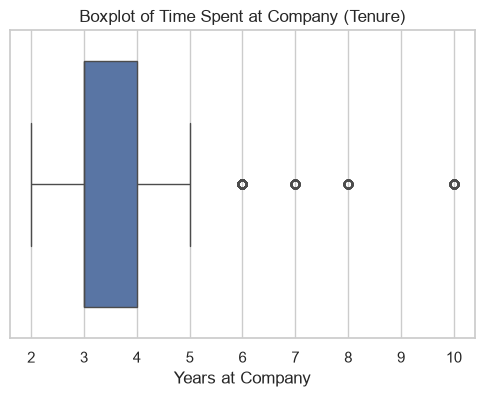

In [10]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect outliers
plt.figure(figsize=(6, 4))
sns.boxplot(x=df_clean['time_spend_company'])
plt.title('Boxplot of Time Spent at Company (Tenure)')
plt.xlabel('Years at Company')
plt.show()

In [11]:
# Determine the number of rows containing outliers
Q1 = df_clean['time_spend_company'].quantile(0.25)
Q3 = df_clean['time_spend_company'].quantile(0.75)
IQR = Q3 - Q1

# Define the upper bound for outliers
upper_bound = Q3 + 1.5 * IQR

# Filter for rows where time_spend_company exceeds the upper bound
outliers = df_clean[df_clean['time_spend_company'] > upper_bound]

print(f"Number of rows containing outliers in 'time_spend_company': {len(outliers)}")

Number of rows containing outliers in 'time_spend_company': 824


### Target Variable Analysis
First, we must quantify the exact class balance of our target variable (`left`). A highly imbalanced dataset will require specific handling (like SMOTE or class weighting) during the modeling phase to ensure the algorithm does not just predict the majority class.

In [12]:
# Get numbers of people who left vs. stayed
print("Counts of employees who left vs. stayed:")
print(df_clean['left'].value_counts())

# Get percentages of people who left vs. stayed
print("\nPercentages of employees who left vs. stayed:")
print(df_clean['left'].value_counts(normalize=True) * 100)

Counts of employees who left vs. stayed:
left
0    10000
1     1991
Name: count, dtype: int64

Percentages of employees who left vs. stayed:
left
0    83.39588
1    16.60412
Name: proportion, dtype: float64


### Bivariate Data Visualizations
We will examine the relationships between our key continuous variables and the target variable to identify potential flight risk thresholds.

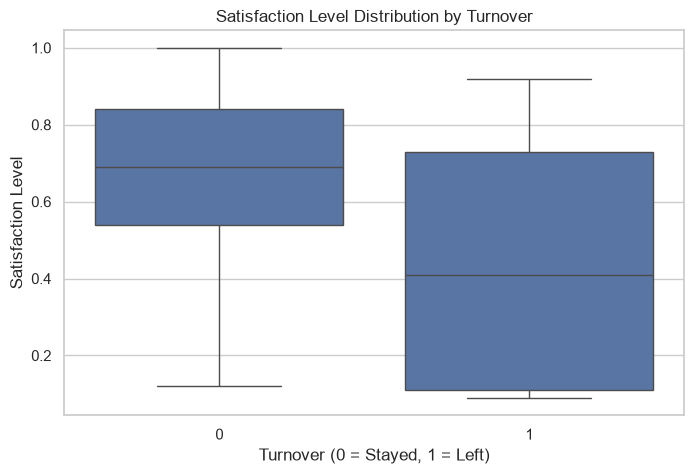

In [13]:
# Plot: Satisfaction Level vs. Turnover
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='left', y='satisfaction_level')
plt.title('Satisfaction Level Distribution by Turnover')
plt.xlabel('Turnover (0 = Stayed, 1 = Left)')
plt.ylabel('Satisfaction Level')
plt.show()

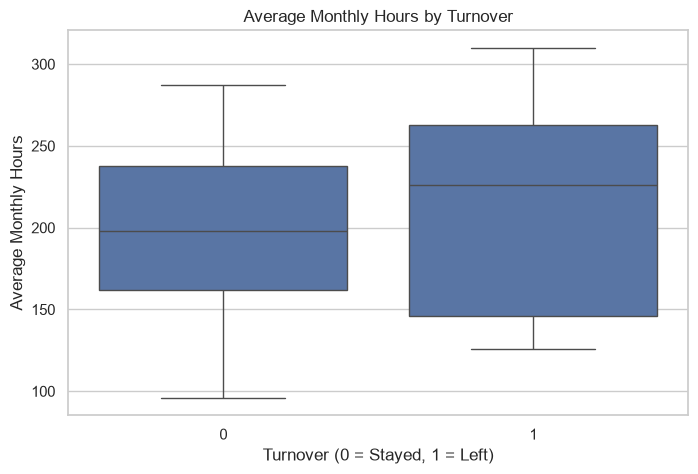

In [14]:
# Plot: Average Monthly Hours vs. Turnover
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='left', y='average_montly_hours')
plt.title('Average Monthly Hours by Turnover')
plt.xlabel('Turnover (0 = Stayed, 1 = Left)')
plt.ylabel('Average Monthly Hours')
plt.show()

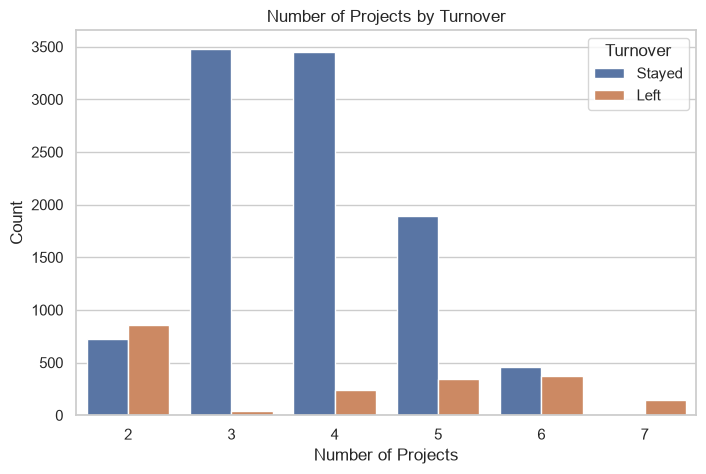

In [15]:
# Plot: Number of Projects vs. Turnover
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='number_project', hue='left')
plt.title('Number of Projects by Turnover')
plt.xlabel('Number of Projects')
plt.ylabel('Count')
plt.legend(title='Turnover', labels=['Stayed', 'Left'])
plt.show()

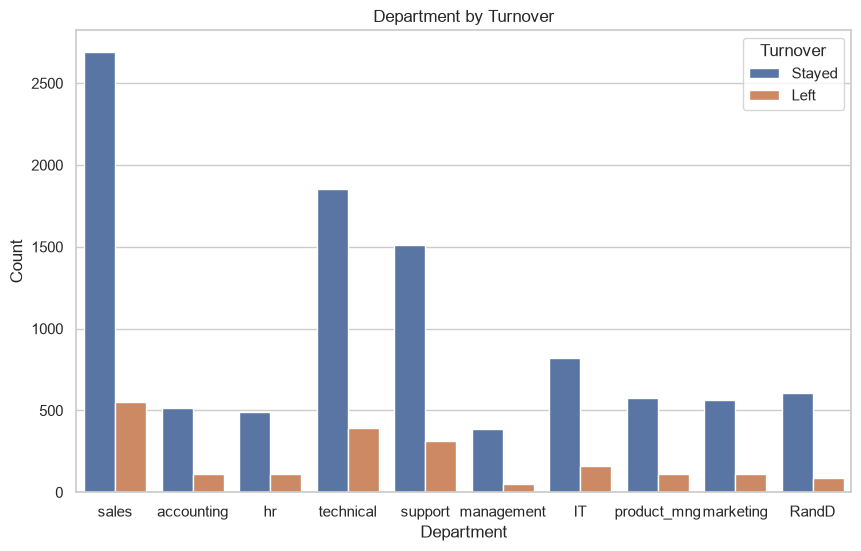

In [21]:
# Plot: Department vs. Turnover
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='Department', hue='left')
plt.title('Department by Turnover')
plt.xlabel('Department')
plt.ylabel('Count')
plt.legend(title='Turnover', labels=['Stayed', 'Left'])
plt.show()


# Phase 3: Construct (Data Preparation and Modeling)

In this phase, we will prepare the dataset for machine learning algorithms. We must encode our categorical variables (`Department` and `salary`) so the models can process them, and then split our data into training and testing sets. We will begin by fitting a baseline Logistic Regression model.

In [17]:
# Create a copy of the clean dataframe to avoid modifying the original
df_encoded = df_clean.copy()

# Ordinal encode the 'salary' column (low=0, medium=1, high=2)
df_encoded['salary'] = df_encoded['salary'].map({'low': 0, 'medium': 1, 'high': 2}, dtype=int)

# Dummy encode the 'Department' column
# We use drop_first=True to avoid multicollinearity (the dummy variable trap)
df_encoded = pd.get_dummies(df_encoded, columns=['Department'], drop_first=True, dtype=int)

# Verify the new encoded columns
df_encoded.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical
0,0.38,0.53,2,157,3,0,1,0,0,0,0,0,0,0,0,1,0,0
1,0.80,0.86,5,262,6,0,1,0,1,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,1,0,1,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,1,0,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,1,0,0,0,0,0,0,0,0,1,0,0


Python (Train-Test Split)
We split the data 80/20. Notice we use stratify=y; this ensures that the 85/15 ratio of retained vs. departed employees is maintained in both the training and testing sets.

In [22]:
from sklearn.model_selection import train_test_split

# Isolate the target variable (y) and the features (X)
y = df_encoded['left']
X = df_encoded.drop('left', axis=1)

# Perform the train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (9592, 17)
Testing set shape: (2399, 17)


We use Logistic Regression as our baseline to check if a simple linear model fits the data well.

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Instantiate the Logistic Regression model
log_clf = LogisticRegression(random_state=42, max_iter=500)

# Fit the model to the training data
log_clf.fit(X_train, y_train)

# Generate predictions on the test set
y_pred_log = log_clf.predict(X_test)

Logistic Regression Classification Report:
---------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      2001
           1       0.50      0.19      0.27       398

    accuracy                           0.83      2399
   macro avg       0.68      0.57      0.59      2399
weighted avg       0.80      0.83      0.80      2399



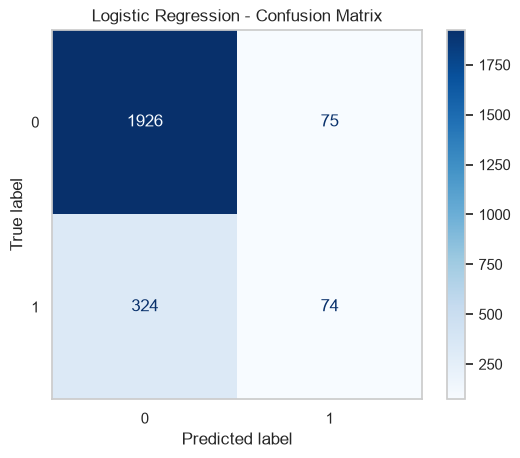

In [24]:
# Print the classification report
print("Logistic Regression Classification Report:")
print("-" * 45)
print(classification_report(y_test, y_pred_log))

# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred_log, labels=log_clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_clf.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Logistic Regression - Confusion Matrix')
plt.grid(False) # Turn off grid lines for a cleaner matrix
plt.show()

This output reveals exactly why we cannot rely on accuracy alone for HR data.While the model has an overall accuracy of 83%, the recall for class 1 (employees who left) is only 0.19. This means the model only successfully identified 19% of the employees who actually quit. For a business trying to proactively retain staff, missing 81% of flight risks is a failure.Logistic Regression requires a linear relationship between the independent variables and the logit of the outcome. Our EDA showed that extreme highs and extreme lows in workload triggered turnover, which is a non-linear relationship.To fix this, we will build a Random Forest Classifier. Tree-based models handle non-linear relationships natively and are robust against outliers.

### Advanced Modeling: Random Forest

Given the poor recall of the Logistic Regression model, we will train a Random Forest Classifier. Tree-based models are better suited for this dataset because they do not assume a linear relationship between features and the target variable, and they can capture complex interactions (e.g., high hours combined with low satisfaction). We will use GridSearchCV to tune the hyperparameters.

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Instantiate the model
rf = RandomForestClassifier(random_state=42)

# Define the hyperparameter grid
cv_params = {
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 2, 5],
    'min_samples_split': [2, 5],
    'n_estimators': [75, 150]
}

# Define the scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Instantiate GridSearchCV, optimizing for 'recall'
rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='recall', n_jobs=-1)

# Fit the model to the training data
rf_cv.fit(X_train, y_train)

# Output the optimal parameters and best cross-validated recall score
print("Random Forest - Best Parameters:", rf_cv.best_params_)
print(f"Random Forest - Best CV Recall Score: {rf_cv.best_score_:.4f}")

Random Forest - Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 75}
Random Forest - Best CV Recall Score: 0.9115


Random Forest Classification Report:
---------------------------------------------
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2001
           1       0.99      0.92      0.96       398

    accuracy                           0.99      2399
   macro avg       0.99      0.96      0.97      2399
weighted avg       0.99      0.99      0.99      2399



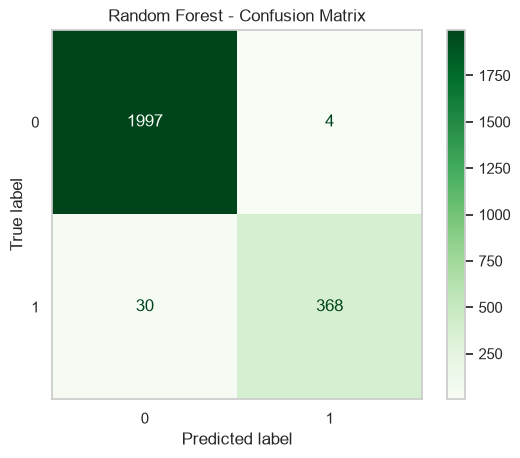

In [27]:
# Use the best estimator to predict on the test set
rf_best = rf_cv.best_estimator_
y_pred_rf = rf_best.predict(X_test)

# Print the classification report
print("Random Forest Classification Report:")
print("-" * 45)
print(classification_report(y_test, y_pred_rf))

# Plot the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=rf_best.classes_)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_best.classes_)
disp_rf.plot(cmap='Greens', values_format='d')
plt.title('Random Forest - Confusion Matrix')
plt.grid(False)
plt.show()

The result shows a massive improvement. The recall for class 1 (employees who left) skyrocketed from 19% to 92%.

This means your new model successfully identified 92% of the employees who actually quit, whereas the previous model missed 81% of them. This proves that the drivers of turnover in this dataset are highly non-linear. Logistic regression failed because it looked for a straight-line relationship, while Random Forest successfully mapped the complex interactions—like employees leaving because they were either severely overworked or severely underutilized.

# Phase 4: Execute (Interpretation and Recommendations)

With a champion model that successfully identifies 92% of turnover risk, we must now interpret *how* it makes those decisions. By extracting the feature importances from the Random Forest model, we can rank the variables that most strongly influence an employee's decision to leave. This will form the foundation of our business recommendations.

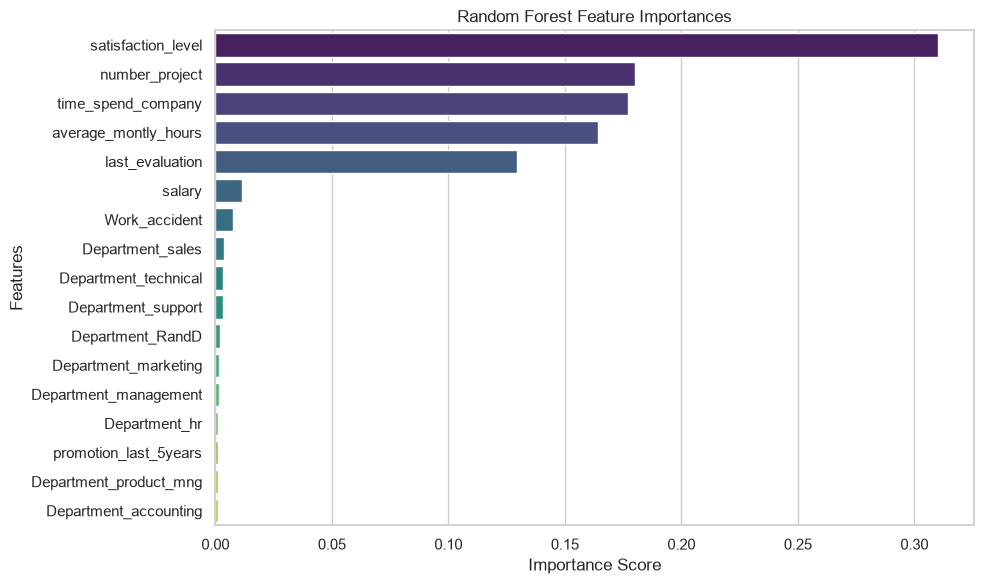

In [28]:
# Extract feature importances from the best Random Forest model
importances = rf_best.feature_importances_

# Create a pandas Series for easy plotting, using the training data column names
feature_importances = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

### Conclusion & Business Recommendations

Based on the feature importances extracted from our Random Forest model, the structural drivers of employee turnover at Salifort Motors are tied directly to workload and tenure, not necessarily department or salary.

**Key Insights:**
1. **Burnout is the primary driver:** Employees with excessive project loads and high average monthly hours are leaving at alarming rates. 
2. **The 4-Year Stagnation:** The model identified `time_spend_company` as a major factor. EDA showed employees hitting the 4-to-5-year mark without a recent promotion are high flight risks.
3. **Satisfaction is a trailing indicator:** While low satisfaction strongly predicts turnover, it is a symptom of the workload issues mentioned above.

**Actionable Recommendations:**
*   **Cap Workloads:** Institute a hard cap on the number of concurrent projects an employee can be assigned. 
*   **Investigate the 4-Year Mark:** HR must audit the promotion pathways for employees approaching their 4th anniversary. If vertical promotion is not possible, lateral movement or skill-development incentives must be introduced.
*   **Overtime Review:** Trigger an automatic HR check-in for any employee consistently logging over 200 hours per month to mitigate immediate burnout risk.